# Imports

In [1]:
import sys
import os
from tqdm import tqdm
import numpy as np
import threading

import numpy.polynomial.polynomial as poly
from scipy.signal import find_peaks, savgol_filter
import h5py

import matplotlib
#matplotlib.use("Agg") # Use non-interactive backend for faster plotting without rendering
import matplotlib.pyplot as plt

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook_connected" # Better for VS Code

# Definition of constants and parameters
h = 4.1357e-15      # eV.s (Plank's constant)
c = 299792458.      # m/s (speed of light)
k_B = 8.61733e-5    # eV/K (Boltzmann's constant)
T = 293.            # K (temperature)

# Importing the data
spectra_file = 'NBG_-100C_860nm_200mW_OD1_OC_900-1200nm_fine001(1).h5' # A random .h5 file in this directory

# Read photoluminescence intensity spectra and wavelengths
cube = h5py.File(spectra_file, 'r')
wvl = np.array(cube['Cube']['Wavelength'])      # nm (wavelengths)
intensity = np.array(cube['Cube']['Images'])    # photons / cm^2.s.eV (Photoluminescence intensity spectra)
intensity *= 1e4                                # Conversion factor from cm^2 to m^2
intensity = np.abs(intensity)                   # Take absolute values of intensity

# Convert wavelengths to photon energy in eV
photon_energy = h * c / (wvl * 1e-9)[::-1] # eV

# Get the curve that will be fitted to obtain the fermi quasi-level split
a = (2 * np.pi * photon_energy[:, None, None] ** 2) / (intensity * h ** 3 * c ** 2)  # Get argument of logarithm
curve_to_fit = np.log(a) # ln(E^2 / I) vs. E (where E = photon energy, I = how much absorbance (intensity) for these photons)

# Reshape the 3d data into 2d data to facilitate iterations
Sw, Sx, Sy = np.shape(curve_to_fit) # Sw = length of wavelength/energy and absorbance/intensity vectors, and therefore curve_to_fit. Sx and Sy: Number of pixels in x and y directions.
curve_to_fit_2d = curve_to_fit.reshape((Sw, Sx * Sy)) # 'Flattens' the image into a long 1D list of curve_to_fit vectors for each pixel (i.e., a 2D array all in all).
intensity_2d = intensity.reshape((Sw, Sx * Sy))


C:\Users\willi\AppData\Local\Temp\ipykernel_18732\3881633821.py:40: RuntimeWarning:

divide by zero encountered in divide



In [ ]:
# Wavelengths shape
wvl.shape

(151,)

In [ ]:
# Absorbance data shape
intensity.shape

(151, 512, 512)

^^512 by 512 pixels^^

## Absorbance Spectrum Plot

In [3]:
# Look at first pixel's absorbance spectrum
intensity_00 = intensity[:, 0, 0]
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(wvl, intensity_00)
fig


<Figure size 800x600 with 1 Axes>

Text(0.5, 1.0, 'Pixel (458, 352)')

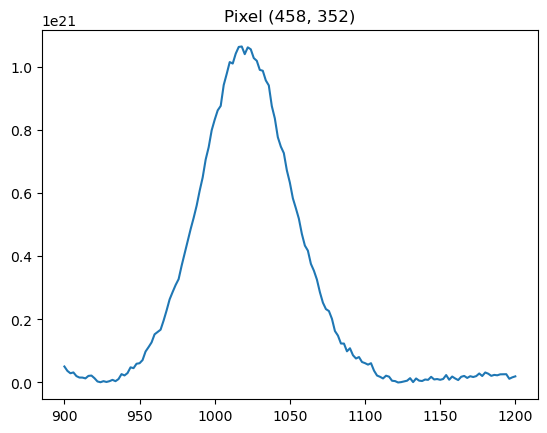

In [107]:
# Check out a random pixel
x = np.random.randint(0, 512)
y = np.random.randint(0, 512)
amp = intensity[:, x, y]
plt.plot(wvl, amp)
plt.title(f'Pixel ({x}, {y})')

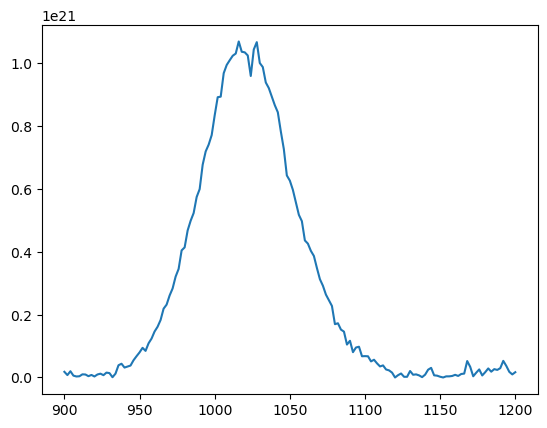

In [10]:
# Closest thing to a double peak on the cube
amp = intensity_2d[:, 128577]
plt.plot(wvl, amp)

## Checking for Multiple Peaks

In [ ]:
for i in tqdm(range(Sx * Sy)):
    amp = intensity_2d[:, i]
    peaks, properties = find_peaks(amp, height=np.max(amp)*0.75, prominence=np.max(amp)*0.10)

    if len(peaks) > 1:
        # Convert flat index back to (x, y) coordinates
        x = i // Sy
        y = i % Sy
        print(f'Multiple peaks at pixel {i} ({x}, {y})')


# Try using gaussian mixutre model
        

  0%|          | 0/262144 [00:00<?, ?it/s]

 46%|████▌     | 119431/262144 [00:05<00:06, 21416.88it/s]

Multiple peaks at pixel 116250 (227, 26)


 51%|█████     | 133272/262144 [00:05<00:05, 22586.28it/s]

Multiple peaks at pixel 128577 (251, 65)


100%|██████████| 262144/262144 [00:10<00:00, 24456.27it/s]


## Smoothing

C:\Users\willi\AppData\Local\Temp\ipykernel_30016\2122777629.py:15: RuntimeWarning:

invalid value encountered in log



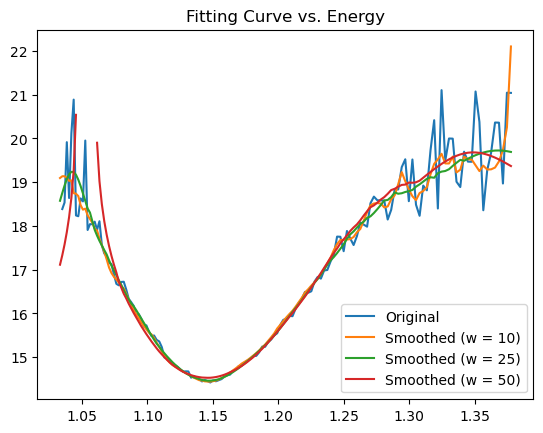

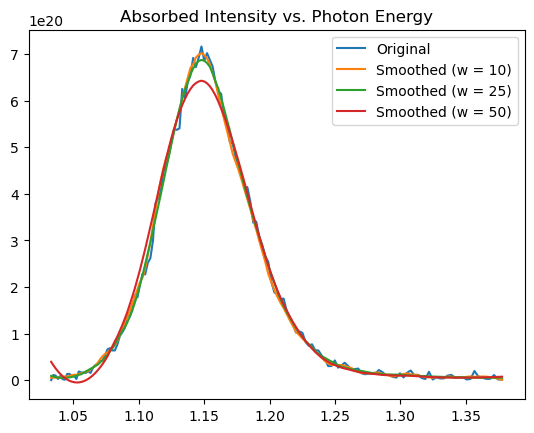

In [4]:
# Using Savitzky-Golay Filtering for smoothing

# Look at first pixel's absorbance spectrum
intensity_00 = intensity[:, 0, 0]
curve_to_fit_00 = curve_to_fit[:, 0, 0]
energy = photon_energy
# Apply filtering (Alter window length for level of smoothing, keep polyorder 2 or 3)
windows = [10, 25, 50]
smoothed_intensity_00 = {}
smoothed_curve_to_fit_00 = {}
for w in windows:
    smoothed_intensity_00[w] = savgol_filter(intensity_00, window_length=w, polyorder=2)
    # Get the curve that will be fitted to obtain the fermi quasi-level split
    a = (2 * np.pi * energy**2) / (smoothed_intensity_00[w] * h ** 3 * c ** 2)  # Get argument of logarithm
    smoothed_curve_to_fit_00[w] = np.log(a) # ln(E^2 / I) vs. E (where E = photon energy, I = how much absorbance (intensity) for these photons)

plt.figure(1)
plt.title('Fitting Curve vs. Energy')
amp = curve_to_fit_00
plt.plot(energy, amp, label='Original')
for w in smoothed_curve_to_fit_00:
    amp = smoothed_curve_to_fit_00[w]
    plt.plot(energy, amp, label=f'Smoothed (w = {w})')
plt.legend()

plt.figure(2)
plt.title('Absorbed Intensity vs. Photon Energy')
amp = intensity_00
plt.plot(energy, amp, label='Original')
for w in smoothed_curve_to_fit_00:
    amp = smoothed_intensity_00[w]
    plt.plot(energy, amp, label=f'Smoothed (w = {w})')
plt.legend()

# Fitting

## Fixed Window

In [ ]:
# The old way (double-check)
def old_fit(energy_i, amp):
        """
        For each point of the cube, the high-energy tail of the curve is selected, and a linear regression is performed.

        :param energy_i: the numpy array of photon energies
        :param amp: the numpy array of y-data to be fitted.
        :return intercept: the intercept of the fitted line (which is the quasi fermi-level divided by - k_B * T)
        """
        # Remove nan and infinite elements from array
        idx = np.squeeze(np.argwhere(np.isfinite(amp)))
        amp = amp[idx]
        energy_i = energy_i[idx]

        # Only keep the high-energy tail of the array (after the minimum value)
        amp_tail = amp[np.argmin(amp):]
        energy_tail = energy_i[np.argmin(amp):]

        # Remove the first and last 10% of data to only keep the linear part of the tail
        percentile_10_amp = np.percentile(amp_tail, 10, interpolation='nearest')
        percentile_90_amp = np.percentile(amp_tail, 90, interpolation='nearest')
        idx_start = np.where(percentile_10_amp == amp_tail)[0][0]
        idx_stop = np.where(percentile_90_amp == amp_tail)[0][0]
        amp_tail_10 = amp_tail[idx_start:idx_stop]
        energy_tail_10 = energy_tail[idx_start:idx_stop]

        if len(energy_tail_10) <= 1:
            intercept = 0
        else:
            # Perform curve fitting of a 1st degree polynomial
            intercept, slope = poly.polyfit(energy_tail_10, amp_tail_10, 1)

        return intercept

# Fit the pixel
intercept_00 = old_fit(energy, curve_to_fit_00)
quasi_fermi_level_split_00 = intercept_00 * -k_B * T  # eV
result = float(quasi_fermi_level_split_00)
print(result)

0.6053334759345828


C:\Users\willi\AppData\Local\Temp\ipykernel_31244\1781051637.py:36: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  intercept_00 = old_fit(energy, curve_to_fit_00)


## Variable Window

In [11]:
def fit(energy, amp, idx_start, idx_stop):
        """
        For each point of the cube, the high-energy tail of the curve is selected, and a linear regression is performed.

        :param energy_i: the numpy array of photon energies
        :param amp: the numpy array of y-data to be fitted.
        :param start: the starting index of the high-energy tail to be fitted
        :param stop: the stopping index of the high-energy tail to be fitted
        :return intercept: the intercept of the fitted line (which is the quasi fermi-level divided by - k_B * T)
        :return slope: the slope of the fitted line
        :return R2: the R^2 value of the fit
        """

        # Crop the data to the (manually selected) high-energy tail
        amp_tail = amp[idx_start:idx_stop]
        energy_tail = energy[idx_start:idx_stop]

        if len(energy_tail) <= 1:
            intercept = 0
            slope = 0
            R2 = 0
        else:
            # Perform curve fitting of a 1st degree polynomial
            intercept, slope = poly.polyfit(energy_tail, amp_tail, 1)
            fitted_line = intercept + slope * energy_tail
            ss_res = np.sum((amp_tail - fitted_line)**2)
            ss_tot = np.sum((amp_tail - np.mean(amp_tail))**2)
            R2 = 1 - ss_res / ss_tot 

        return intercept, slope, R2

Intercept: -19.27, Quasi-Fermi Level Split: 0.49 eV
Start index: 60 (1.17 eV), Stop index: 137 (1.36 eV)
Number of points: 77


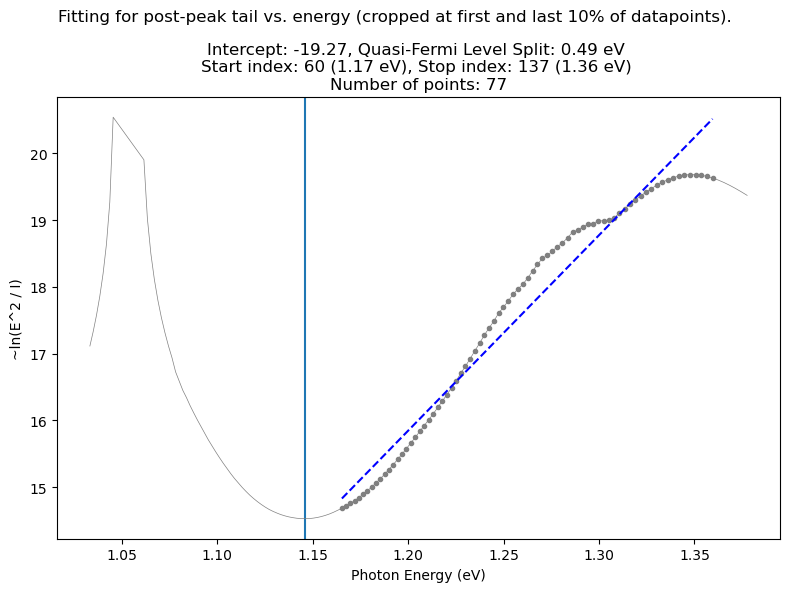

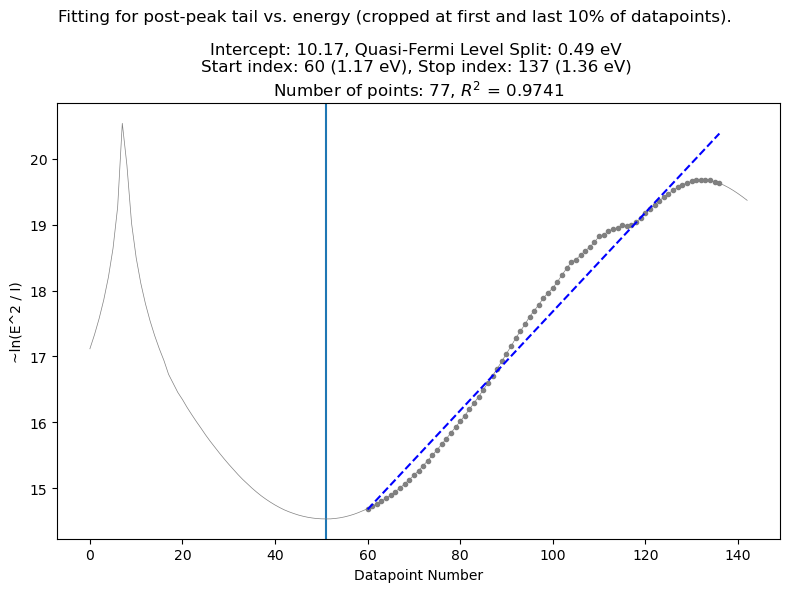

In [7]:
# Fitting between first and last 10% of tail

# Selecting first pixel
curve_to_fit_00 = curve_to_fit[:, 0, 0]
energy = photon_energy

# Select which curve to fit
#amp = curve_to_fit_00
amp = smoothed_curve_to_fit_00[50]

# Remove nan and infinite elements from array
idx = np.squeeze(np.argwhere(np.isfinite(amp)))
amp = amp[idx]
energy = energy[idx]
# Only keep the high-energy tail of the array (after the minimum value)
idx_peak = np.argmin(amp)
amp_tail = amp[idx_peak:]

# Remove the first and last 10% of data to only keep the linear part of the tail
percentile_10_amp = np.percentile(amp_tail, 10, interpolation='nearest')
percentile_90_amp = np.percentile(amp_tail, 90, interpolation='nearest')
idx_start = idx_peak + np.argmin(np.abs(amp_tail - percentile_10_amp)) # Finding the index where percentile_10_amp == amp_tail (or as close as possible)
idx_stop = idx_peak + np.argmin(np.abs(amp_tail - percentile_90_amp))

# Fit the pixel
intercept, slope, R2 = fit(energy, amp, idx_start, idx_stop)
qfls = intercept * -k_B * T  # eV
qfls = float(qfls)
print(f'Intercept: {intercept:.2f}, Quasi-Fermi Level Split: {qfls:.2f} eV')
print(f"Start index: {idx_start} ({energy[idx_start]:.2f} eV), Stop index: {idx_stop} ({energy[idx_stop]:.2f} eV)")
print(f'Number of points: {idx_stop - idx_start}')

# Visualization
plt.figure(1, figsize=(8, 6))
plt.axvline(x=energy[idx_peak])
plt.plot(energy, amp, linewidth=0.5, color='grey')
plt.plot(energy[idx_start:idx_stop], amp[idx_start:idx_stop], color='grey', linestyle='none', marker='o', markersize=3)
trendline_x = energy[idx_start:idx_stop]
trendline_y = intercept + slope * trendline_x
plt.plot(trendline_x, trendline_y, color='blue', linestyle='--')

plt.xlabel('Photon Energy (eV)')
plt.ylabel('~ln(E^2 / I)')
plt.title(
    f'Intercept: {intercept:.2f}, Quasi-Fermi Level Split: {qfls:.2f} eV \n' + 
    f'Start index: {idx_start} ({energy[idx_start]:.2f} eV), Stop index: {idx_stop} ({energy[idx_stop]:.2f} eV) \n' + 
    f'Number of points: {idx_stop - idx_start}'
)
plt.suptitle('Fitting for post-peak tail vs. energy (cropped at first and last 10% of datapoints).')
plt.tight_layout()

# Visualization (idx)
idx = np.arange(len(amp))
intercept, slope, R2 = fit(idx, amp, idx_start, idx_stop)
plt.figure(2, figsize=(8, 6))
plt.axvline(x=float(idx_peak))
plt.plot(idx, amp, linewidth=0.5, color='grey')
plt.plot(idx[idx_start:idx_stop], amp[idx_start:idx_stop], color='grey', linestyle='none', marker='o', markersize=3)
trendline_x = idx[idx_start:idx_stop]
trendline_y = intercept + slope * trendline_x
plt.plot(trendline_x, trendline_y, color='blue', linestyle='--')

plt.xlabel('Datapoint Number')
plt.ylabel('~ln(E^2 / I)')
plt.title(
    f'Intercept: {intercept:.2f}, Quasi-Fermi Level Split: {qfls:.2f} eV \n' + 
    f'Start index: {idx_start} ({energy[idx_start]:.2f} eV), Stop index: {idx_stop} ({energy[idx_stop]:.2f} eV) \n' + 
    f'Number of points: {idx_stop - idx_start}, $R^2$ = {R2:.4f}'
)
plt.suptitle('Fitting for post-peak tail vs. energy (cropped at first and last 10% of datapoints).')
plt.tight_layout()

### Sweeping Start OR Stop Indices

Text(0.5, 1.0, 'Quasi Fermi-level split vs. stopping energy of fitting window')

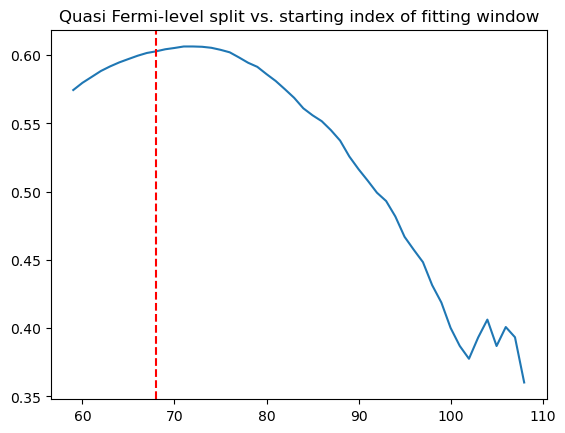

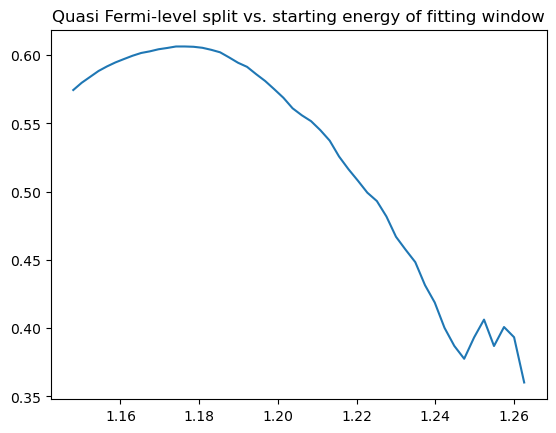

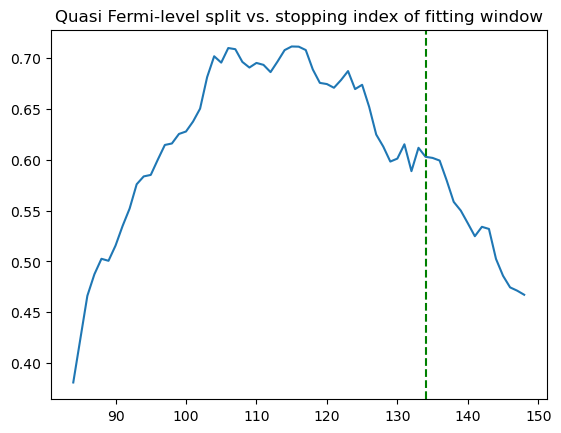

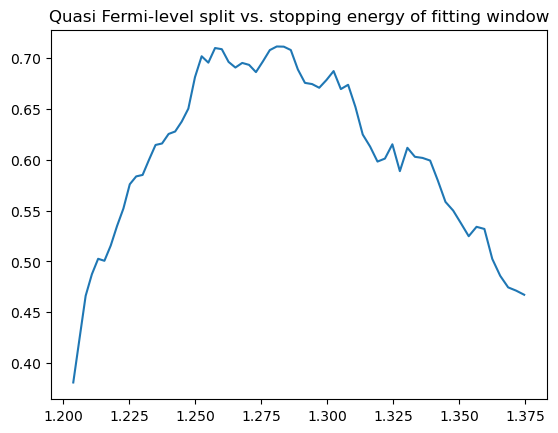

In [10]:
# Selecting First Pixel
curve_to_fit_00 = curve_to_fit[:, 0, 0]
# Fitting just one pixel
amp = curve_to_fit_00
# Remove nan and infinite elements from array
idx = np.squeeze(np.argwhere(np.isfinite(amp)))
amp = amp[idx]
energy = photon_energy[idx]
# Only keep the high-energy tail of the array (after the minimum value)
idx_peak = np.argmin(amp)
amp_tail = amp[idx_peak:]
# Remove the first and last 10% of data to only keep the linear part of the tail
percentile_10_amp = np.percentile(amp_tail, 10, interpolation='nearest')
percentile_90_amp = np.percentile(amp_tail, 90, interpolation='nearest')
# Preserving 10th percentile start/stop indices
idx_start_10 = idx_peak + np.where(percentile_10_amp == amp_tail)[0][0]
idx_stop_10 = idx_peak + np.where(percentile_90_amp == amp_tail)[0][0]

# Testing different starting points
starting_indices = range(idx_peak, idx_peak + 50)
starting_results = []
for idx_start in starting_indices:
    # Fit the pixel
    intercept_00, *_ = fit(energy, curve_to_fit_00, idx_start, idx_stop_10)
    quasi_fermi_level_split_00 = intercept_00 * -k_B * T  # eV
    result = float(quasi_fermi_level_split_00)
    starting_results.append(result)

plt.figure(1)
plt.plot(starting_indices, starting_results)
plt.axvline(x=idx_start_10, color='r', linestyle='--', label='10th percentile start index')
plt.title("Quasi Fermi-level split vs. starting index of fitting window")
starting_energies = energy[starting_indices]
plt.figure(2)
plt.plot(starting_energies, starting_results)
plt.title("Quasi Fermi-level split vs. starting energy of fitting window")


# Testing different stopping points
stopping_indices = range(idx_stop_10 - 50, len(amp)-1)
stopping_results = []
for idx_stop in stopping_indices:
    # Fit the pixel
    intercept_00, *_ = fit(energy, curve_to_fit_00, idx_start_10, idx_stop)
    quasi_fermi_level_split_00 = intercept_00 * -k_B * T  # eV
    result = float(quasi_fermi_level_split_00)
    stopping_results.append(result)

plt.figure(3)
plt.plot(stopping_indices, stopping_results)
plt.axvline(x=idx_stop_10, color='g', linestyle='--', label='10th percentile stop index')
plt.title("Quasi Fermi-level split vs. stopping index of fitting window")
stopping_energies = energy[stopping_indices]
plt.figure(4)
plt.plot(stopping_energies, stopping_results)
plt.title("Quasi Fermi-level split vs. stopping energy of fitting window")

### Grid of Start/Stop Index Pairs

#### Plotting Surface

In [ ]:
# Selecting First Pixel
curve_to_fit_00 = curve_to_fit[:, 0, 0]
energy = photon_energy

# Selecting which curve to fit
amp = curve_to_fit_00
#amp = smoothed_curve_to_fit_00[10] # Smoothing window width = 50

# Remove nan and infinite elements from array
idx = np.squeeze(np.argwhere(np.isfinite(amp)))
amp = amp[idx]
energy = energy[idx]
# Only keep the high-energy tail of the array (after the minimum value)
idx_peak = np.argmin(amp)
amp_tail = amp[idx_peak:]
# Remove the first and last 10% of data to only keep the linear part of the tail
percentile_10_amp = np.percentile(amp_tail, 10, interpolation='nearest')
percentile_90_amp = np.percentile(amp_tail, 90, interpolation='nearest')
# Preserving 10th percentile start/stop indices
idx_start_10 = idx_peak + np.argmin(np.abs(amp_tail - percentile_10_amp)) # Finding the index where percentile_10_amp == amp_tail (or as close as possible)
idx_stop_10 = idx_peak + np.argmin(np.abs(amp_tail - percentile_90_amp))

# Selecting Start/Stop Index Gridpoints
dist = 20 # How far to either side of the 10th percentile start/stop indices
idx_max = len(energy) - 1
#starting_indices = range(76 - dist, 76 + dist)
#stopping_indices = range(121 - dist, min(121 + dist, idx_max))
#starting_indices = range(idx_peak, 80)
#stopping_indices = range(120 - dist, 120)
starting_indices = range(idx_peak, idx_max)
stopping_indices = range(idx_peak, idx_max)

rows = []
columns = ['start idx', 'stop idx', 'intercept', 'slope', 'R2', 'qfls']
for idx_start in starting_indices:
    for idx_stop in stopping_indices:
        # Check for valid start:stop window
        if idx_stop <= idx_start:
            continue
        # Fit the pixel
        intercept, slope, R2 = fit(energy, amp, idx_start, idx_stop)
        qfls = intercept * -k_B * T  # Quasi Fermi Level Splitting [eV]
        qfls = float(qfls)
        rows.append([idx_start, idx_stop, intercept, slope, R2, qfls])

df = pd.DataFrame(rows, columns=columns)
df['start energy'] = energy[df['start idx']]
df['stop energy'] = energy[df['stop idx']]
df['idx width'] = df['stop idx'] - df['start idx']
df['energy width'] = df['stop energy'] - df['start energy']

# Crop to only accurate fits (R^2 > 0.95)
#df = df[df['R2'] > 0.999]

def plot_surface(xy_mode, z_mode):
    '''  
    Plots either the intercept or QFLS as a function of either the start/stop indices or the start/stop energies.

    :param xy_mode: 'index' or 'energy', whether to plot as a function of start/stop indices or energies.
    :param z_mode: 'qfls' or 'intercept', whether to plot the quasi fermi-level split or the intercept of the fitted line.
    '''
    global df
    # Slelecting which type of data to plot
    if xy_mode == 'index':
        x_values = 'start idx'
        y_values = 'stop idx'
        w_values = 'idx width'
        xaxis_title = "Start"
        yaxis_title = "Stop"
        xaxis_hover = "Start: %{x} <br>"
        yaxis_hover = "Stop: %{y} <br>"
        w_hover = "Width: %{customdata} <br>"
    elif xy_mode == 'energy':
        x_values = 'start energy'
        y_values = 'stop energy'
        w_values = 'energy width'
        xaxis_title = "Start [eV]"
        yaxis_title = "Stop [eV]"
        xaxis_hover = "Start: %{x:.2f} ev<br>"
        yaxis_hover = "Stop: %{y:.2f} eV<br>"
        w_hover = "Width: %{customdata:.2f} eV<br>"
    if z_mode == 'qfls':
        z_values = 'qfls'
        zaxis_title = "QFLS [eV]"
        zaxis_hover = "QFLS: %{z:.2f} eV<extra></extra>"
    elif z_mode == 'intercept':
        z_values = 'intercept'
        zaxis_title = "Intercept"
        zaxis_hover = "Intercept: %{z:.2f} <extra></extra>"
    elif z_mode == 'slope':
        z_values = 'slope'
        zaxis_title = "Slope"
        zaxis_hover = "Slope: %{z:.2f} <extra></extra>"
    elif z_mode == 'R2':
        z_values = 'R2'
        zaxis_title = "R^2"
        zaxis_hover = "R^2: %{z:.4f} <extra></extra>"
    z_grid = df.pivot(index=y_values, columns=x_values, values=z_values)
    w_grid = df.pivot(index=x_values, columns=y_values, values=w_values)


    # Plotting using plotly:

    # Use this for better hover
    hover = xaxis_hover + yaxis_hover + w_hover + zaxis_hover
    # Makes each width value a 1-item list (array), because customdata likes having a list for each pixel (kind of like the hyperspectral data...)
    w_3d = np.expand_dims(w_grid.values, axis=-1) 
    # Create the surface plot
    fig = go.Figure(
        data = [go.Surface(
            x=z_grid.columns, 
            y=z_grid.index, 
            z=z_grid.values, 
            customdata = w_3d, 
            hovertemplate=hover
        )]
    )
    # Add the axis labels
    fig.update_layout(
        scene=dict(
            xaxis_title=xaxis_title,
            yaxis_title=yaxis_title,
            zaxis_title=zaxis_title
        )
    )
    fig.update_layout(
        autosize=False,
        width=1200,  # Desired width in pixels
        height=700   # Desired height in pixels
    )

    fig.show()
        

plot_surface('energy', 'intercept')

In [27]:
df

,start idx,stop idx,intercept,slope,R2,qfls,start energy,stop energy,idx width,energy width
0,59,60,0.000000,0.000000,0.000000,-0.000000,1.148011,1.150141,1,0.002130
1,59,61,-10.908774,22.065981,1.000000,0.275433,1.148011,1.152279,2,0.004268
2,59,62,7.055910,6.427132,0.337401,-0.178153,1.148011,1.154424,3,0.006413
3,59,63,7.145258,6.349400,0.554941,-0.180409,1.148011,1.156578,4,0.008567
4,59,64,5.908687,7.424540,0.761619,-0.149187,1.148011,1.158740,5,0.010729
...,...,...,...,...,...,...,...,...,...,...
4000,145,147,21.963023,-1.170709,1.000000,-0.554539,1.365475,1.371517,2,0.006042
4001,145,148,335.830457,-230.860903,0.752999,-8.479308,1.365475,1.374558,3,0.009083
4002,146,147,0.000000,0.000000,0.000000,-0.000000,1.368490,1.371517,1,0.003028
4003,146,148,648.775432,-459.202954,1.000000,-16.380786,1.368490,1.374558,2,0.006069


#### Plotting Trendlines

In [ ]:
# Generating plots for each fitting window
path, filename_ext = os.path.split(spectra_file)
filename = os.path.splitext(filename_ext)[0]
#image_folder = os.path.join(path, filename + '-fitting_window_visualizations-pixel_00')
image_folder = os.path.join(path, filename + '-fitting_window_visualizations-pixel_00_smoothed_50')
os.makedirs(image_folder, exist_ok=True)

for idx, row in tqdm(df.iterrows()): 
    idx_start = int(row['start idx'])
    idx_stop = int(row['stop idx'])
    intercept = row['intercept']
    slope = row['slope']
    qfls = row['qfls']
    plt.figure(figsize=(8, 6))
    plt.plot(energy, amp, linewidth=0.5, color='grey') # Plot the whole curve for pixel 00
    plt.plot(energy[idx_start:idx_stop], amp[idx_start:idx_stop], color='grey', linestyle='none', marker='o', markersize=3)
    trendline_x = energy[idx_start:idx_stop]
    trendline_y = intercept + slope * trendline_x
    plt.plot(trendline_x, trendline_y, color='blue', linestyle='--')
    plt.xlabel('Photon Energy (eV)')
    plt.ylabel('~ ln(E^2 / I)')
    plt.title(
        f'Intercept: {intercept:.2f}, Quasi-Fermi Level Split: {qfls:.2f} eV \n' + 
        f'Start index: {idx_start} ({energy[idx_start]:.2f} eV), Stop index: {idx_stop} ({energy[idx_stop]:.2f} eV) \n' + 
        f'Number of points: {idx_stop - idx_start}'
    )
    plt.savefig(os.path.join(image_folder, f'start_{idx_start}-stop_{idx_stop}.png'), dpi=300, bbox_inches="tight")
    plt.close()

4095it [13:58,  4.88it/s]


#### Distribution of Fits

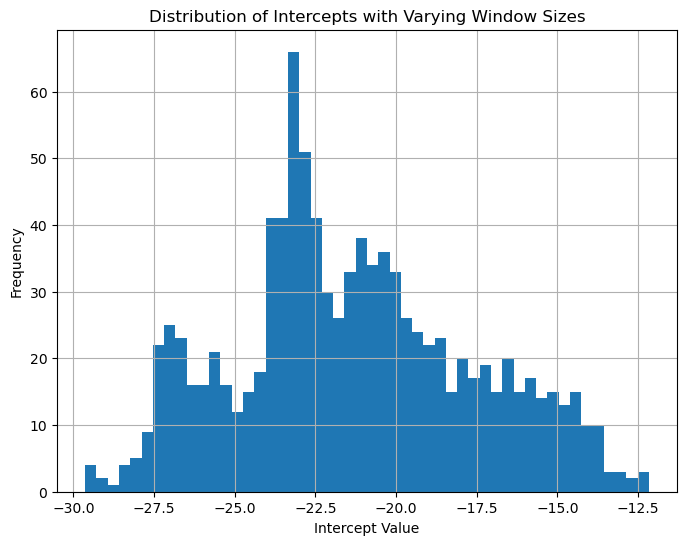

In [53]:
plt.figure(figsize=(8, 6))
df['intercept'].hist(bins=50)
plt.title('Distribution of Intercepts with Varying Window Sizes')
plt.xlabel('Intercept Value')
plt.ylabel('Frequency')
plt.show()

## Iterating over Cube

### Not sure what this is but I'm not deleting it

In [ ]:
# Fitting EVERY pixel

# Loop through each spatial point to get the intercept of the high-energy tail fit
intercepts_list = [fit(energy, curve) for curve in curve_to_fit_2d.T]
intercepts = np.array(intercepts_list)

# Get the quasi fermi-level splittings from the intercepts
quasi_fermi_level_split = intercepts * -k_B * T  # eV
fermi_map = quasi_fermi_level_split.reshape((Sx, Sy))

# Saving data
'''
# Save the map of quasi fermi-level splittings as an HDF5 cube
fermi_filename = filename + '_fermi.h5'
fermi_file = h5py.File(os.path.join(path, fermi_filename), 'w')  # Create new HDF5 file
fermi_file.create_dataset("Cube/Images", data=fermi_map)         # Save the fermi levels in the cube
cube.copy('Cube/Info', fermi_file['Cube'])                       # Copy the info from the input cube
fermi_file['Cube']['Info']['Cube'].attrs['PixelUnit'] = 'eV'     # Change the unit to eV
'''


### Getting best R^2 fit for each pixel

In [ ]:
# Using 1 in 20 pixels (will take a while)
fit_rows = []
columns = ['x', 'y', 'flat pixel number', 'start idx', 'stop idx', 'intercept', 'slope', 'R2']
for i in tqdm(range(0, Sx*Sy)):
    amp = curve_to_fit_2d[:, i]
    # Remove nan and infinite elements from array
    mask = np.isfinite(amp)
    amp = amp[mask]
    energy = photon_energy[mask]
    # Below is the old method of choosing start/stop index ranges, this is less efficient than choosing manually.
    '''
    # Only keep the high-energy tail of the array (after the minimum value)
    idx_peak = np.argmin(amp)
    amp_tail = amp[idx_peak:]
    # Remove the first and last 10% of data to only keep the linear part of the tail
    percentile_10_amp = np.percentile(amp_tail, 10, interpolation='nearest')
    percentile_90_amp = np.percentile(amp_tail, 90, interpolation='nearest')
    # Preserving 10th percentile start/stop indices
    idx_start_10 = idx_peak + np.argmin(np.abs(amp_tail - percentile_10_amp)) # Finding the index where percentile_10_amp == amp_tail (or as close as possible)
    idx_stop_10 = idx_peak + np.argmin(np.abs(amp_tail - percentile_90_amp))
    '''
    # Manually chosen start/stop index ranges (based on the distribution of start/stop indices for good fits)
    idx_start_low = 65
    idx_start_high = 85
    idx_stop_high = 115
    # Find the best fit among different fitting windows
    rows = []
    R2s = []
    min_width = 15 # Define a minimum width requirement to avoid overfitting
    for idx_start in range(idx_start_low, idx_start_high):
        for idx_stop in range(idx_start + min_width, idx_stop_high): # Ensures the window is always at least min_width wide
            # Fit the pixel
            intercept, slope, R2 = fit(energy, amp, idx_start, idx_stop)
            rows.append([idx_start, idx_stop, intercept, slope, R2])
            R2s.append(R2)
    # Find the best fit (could use score=R2*width, or minimum width requirement which is what I'll do above).
    best_idx = np.argmax(R2s)
    x = i // Sy
    y = i % Sy
    fit_rows.append([x, y, i] + rows[best_idx])

best_fits_df = pd.DataFrame(fit_rows, columns=columns)

'''
# Doing this now so the data gets saved:
best_fits_df['start energy'] = photon_energy[best_fits_df['start idx']]
best_fits_df['stop energy'] = photon_energy[best_fits_df['stop idx']]
best_fits_df['idx width'] = best_fits_df['stop idx'] - best_fits_df['start idx']
best_fits_df['energy width'] = best_fits_df['stop energy'] - best_fits_df['start energy']
best_fits_df['qfls'] = best_fits_df['intercept'] * -k_B * T

# Saving data
path, filename_ext = os.path.split(spectra_file)
filename = os.path.splitext(filename_ext)[0]
best_fits_df_filename_ext = filename + '_best_fits-min_window_15-full_resolution.csv'
best_fits_df.to_csv(best_fits_df_filename_ext, index=False)
'''

100%|██████████| 262144/262144 [2:17:48<00:00, 31.70it/s]  


In [23]:
best_fits_df['start energy'] = photon_energy[best_fits_df['start idx']]
best_fits_df['stop energy'] = photon_energy[best_fits_df['stop idx']]
best_fits_df['idx width'] = best_fits_df['stop idx'] - best_fits_df['start idx']
best_fits_df['energy width'] = best_fits_df['stop energy'] - best_fits_df['start energy']
best_fits_df['qfls'] = best_fits_df['intercept'] * -k_B * T

In [15]:
best_fits_df 

,x,y,flat pixel number,start idx,stop idx,intercept,slope,R2,start energy,stop energy,idx width,energy width,qfls
0,0,0,0,75,100,-29.319168,37.470277,0.993917,1.180811,1.239852,25,0.059041,0.740273
1,0,100,100,73,97,-28.539437,36.783067,0.996065,1.176330,1.232457,24,0.056127,0.720586
2,0,200,200,67,82,-15.935068,26.172322,0.992059,1.163088,1.196768,15,0.033680,0.402341
3,0,300,300,75,101,-24.554767,33.179343,0.996304,1.180811,1.242336,26,0.061525,0.619978
4,0,400,400,70,85,-25.487901,34.010947,0.994814,1.169671,1.203739,15,0.034068,0.643538
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2617,511,68,261700,70,88,-24.751204,33.543934,0.997520,1.169671,1.210793,18,0.041121,0.624938
2618,511,168,261800,75,91,-27.452497,35.732240,0.997209,1.180811,1.217929,16,0.037118,0.693142
2619,511,268,261900,75,91,-28.246352,36.363076,0.996210,1.180811,1.217929,16,0.037118,0.713186
2620,511,368,262000,71,87,-20.201731,29.494807,0.996438,1.171882,1.208432,16,0.036550,0.510069


In [ ]:
# Saving data
path, filename_ext = os.path.split(spectra_file)
filename = os.path.splitext(filename_ext)[0]
#best_fits_df_filename_ext = filename + '_best_fits.csv'
#best_fits_df_filename_ext = filename + '_best_fits-min_window_10.csv'
#best_fits_df_filename_ext = filename + '_best_fits-min_window_15.csv'
#best_fits_df_filename_ext = filename + '_best_fits-min_window_15-114x114.csv'
best_fits_df_filename_ext = None
best_fits_df.to_csv(best_fits_df_filename_ext, index=False)

### Visualization

In [2]:
# Retreiving data
path, filename_ext = os.path.split(spectra_file)
filename = os.path.splitext(filename_ext)[0]
#best_fits_df_filename_ext = filename + '_best_fits-min_window_10.csv'
best_fits_df_filename_ext = filename + '_best_fits-min_window_15-full_resolution.csv'
best_fits_df = pd.read_csv(best_fits_df_filename_ext)

array([[<Axes: title={'center': 'slope'}>]], dtype=object)

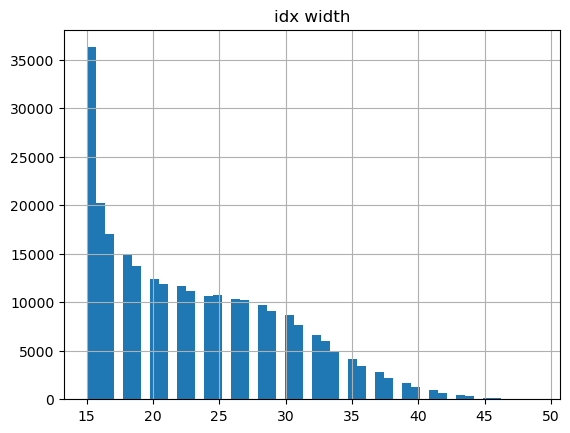

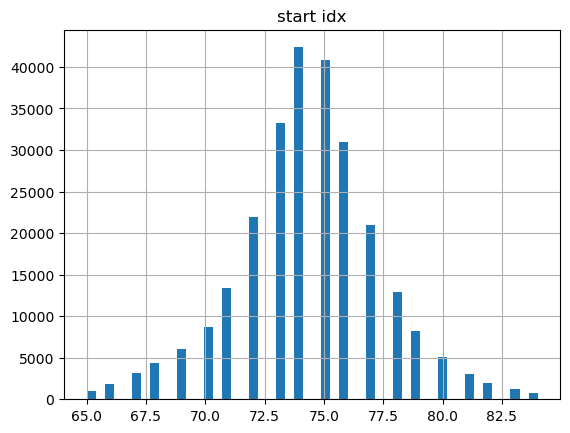

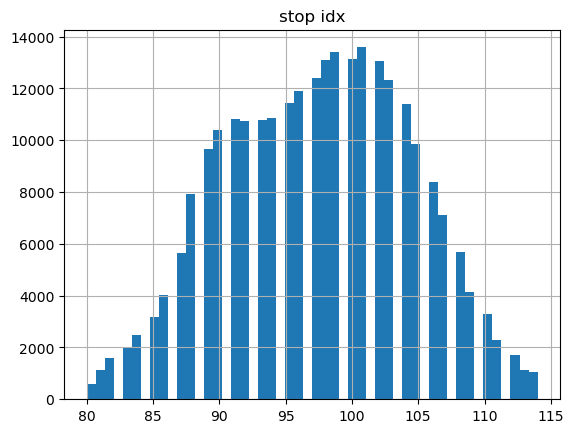

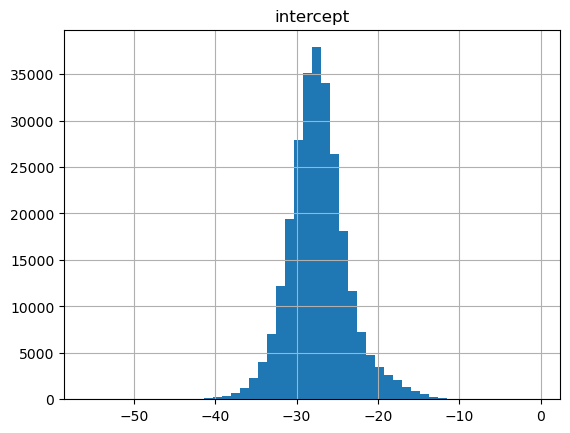

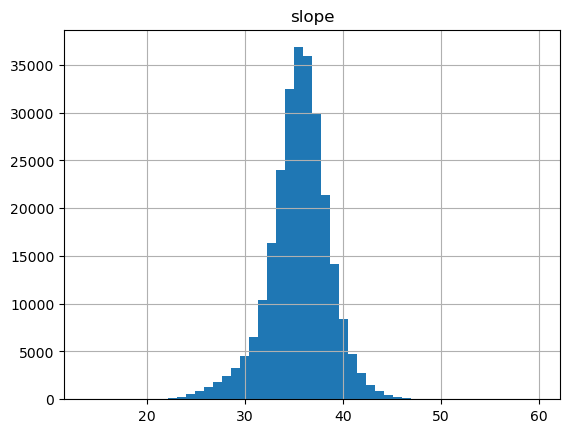

In [6]:
best_fits_df.hist(column='idx width', bins=50)
best_fits_df.hist(column = 'start idx', bins=50)
best_fits_df.hist(column = 'stop idx', bins=50)
best_fits_df.hist(column = 'intercept', bins=50)
best_fits_df['energy slope'] = best_fits_df['slope'] / (k_B*T)
best_fits_df.hist(column = 'slope', bins=50)

In [5]:
1 / (k_B*T)

39.605878889127496

In [7]:
best_fits_df['slope err'] = (best_fits_df['slope'] - k_B*T) / (1 / (k_B*T))

Reasonable start/stop ranges are:

- Start: 65-85
- Stop: 75 - 115

In [18]:
# An example of how the range of start and stop indices are found

random_pixel_number = 128577
amp = curve_to_fit_2d[:, 128577]
# Remove nan and infinite elements from array
idx = np.squeeze(np.argwhere(np.isfinite(amp)))
amp = amp[idx]
energy = photon_energy[idx]
# Only keep the high-energy tail of the array (after the minimum value)
idx_peak = np.argmin(amp)
amp_tail = amp[idx_peak:]
# Remove the first and last 10% of data to only keep the linear part of the tail
percentile_10_amp = np.percentile(amp_tail, 10, interpolation='nearest')
percentile_90_amp = np.percentile(amp_tail, 90, interpolation='nearest')
# Preserving 10th percentile start/stop indices
idx_start_10 = idx_peak + np.argmin(np.abs(amp_tail - percentile_10_amp)) # Finding the index where percentile_10_amp == amp_tail (or as close as possible)
idx_stop_10 = idx_peak + np.argmin(np.abs(amp_tail - percentile_90_amp))

print(f'10th percentile start index: {idx_start_10} ({energy[idx_start_10]:.2f} eV), 10th percentile stop index: {idx_stop_10} ({energy[idx_stop_10]:.2f} eV)')
print(f'Number of start/stop indices tested: {idx_stop_10 - idx_start_10}, so number of iterations = {(idx_stop_10 - idx_start_10)**2}')

10th percentile start index: 67 (1.16 eV), 10th percentile stop index: 123 (1.30 eV)
Number of start/stop indices tested: 56, so number of iterations = 3136


Current number of iterations:
- Start: 67-123
- Stop: 67-123
- Total it. per pixel: $(123 - 67)^2 = 3136$ 
- $512^2 \text{ pixels} \times \frac{1}{100} \text{ chosen} = 2621$ pixels
- Total it.: $3136 \times 2621 = 8219456$ iterations


With reasonable start/stop ranges:
- Start: 65-85
- Stop: 75-115
- Total it. per pixel: $20 \times 40 = 800$
- Total it.: $800 \times 2621 = 2096800$ iterations

It becomes ~4x faster, so we can move from $\frac{1}{100}$ attenuation to $\frac{1}{25}$ and expect about 10 minutes of calculation time.

In [37]:
intercept_grid

x,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
y,,,,,,,,,,,,,,,,,,,,,
0,-29.319168,-31.583477,-25.156462,-28.178933,-24.470784,-29.757705,-29.890678,-28.549652,-22.965902,-23.926630,...,-28.492441,-34.042167,-27.624736,-31.966924,-28.822969,-34.925073,-33.451608,-22.328960,-27.317977,-27.676156
1,-24.809140,-25.138207,-35.899897,-18.710675,-30.093179,-23.753678,-27.497465,-26.839341,-24.266012,-29.566475,...,-25.749055,-33.787942,-30.223560,-27.257446,-27.477642,-23.450342,-31.473287,-26.854359,-14.987972,-32.775370
2,-27.357270,-28.649558,-28.195067,-27.919183,-26.449479,-31.802673,-30.399506,-28.578277,-24.392320,-31.284948,...,-29.753754,-31.164962,-29.778598,-27.949385,-28.972885,-16.950031,-16.350449,-28.092939,-19.580491,-18.780818
3,-24.614377,-23.306590,-26.228354,-27.433505,-26.592964,-23.380508,-28.053830,-26.338560,-29.317027,-23.748557,...,-29.660552,-33.692753,-29.387830,-34.732273,-26.366529,-27.602824,-29.906109,-28.818139,-27.442240,-27.440579
4,-23.127273,-21.823221,-18.003040,-20.040351,-21.057664,-25.858505,-27.162058,-27.878792,-23.543143,-25.687555,...,-30.259501,-33.620284,-29.361632,-30.247674,-28.243321,-27.044774,-27.421683,-30.658392,-25.253951,-27.330731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507,-23.970041,-29.694468,-34.420005,-31.701004,-28.929950,-32.012359,-32.391274,-32.303734,-32.000856,-36.569256,...,-15.529415,-24.651580,-30.211974,-28.614860,-26.154971,-25.942963,-32.580704,-18.033648,-29.427141,-30.635433
508,-23.412804,-30.758663,-28.669264,-27.817227,-30.778266,-27.868589,-34.847618,-26.257157,-27.479730,-29.185568,...,-26.736823,-27.078453,-30.257487,-19.204972,-28.210419,-25.437871,-25.813274,-24.861041,-30.026108,-17.759029
509,-31.861104,-25.117930,-27.400992,-26.491115,-29.514074,-25.209365,-30.512286,-27.114047,-29.878237,-26.477948,...,-21.109583,-24.237345,-26.704180,-25.805068,-25.693742,-31.245436,-28.023012,-23.012603,-31.958667,-23.127793


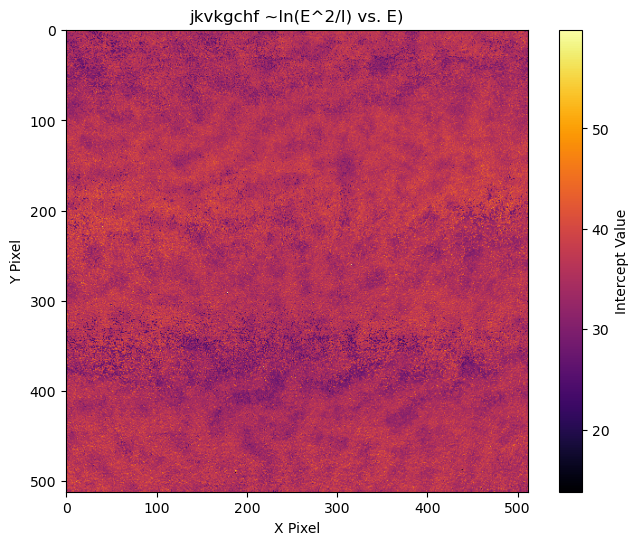

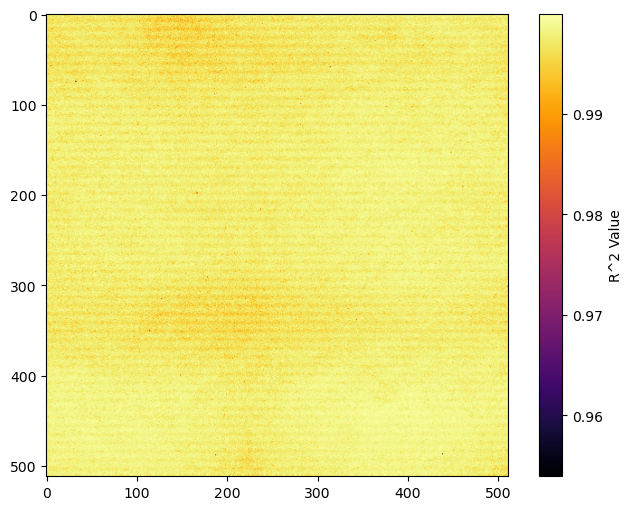

In [9]:
# Image of intercept vs location

intercept_grid = best_fits_df.pivot(index='y', columns='x', values='slope')

plt.figure(figsize=(8, 6))

plt.imshow(intercept_grid, cmap='inferno')
plt.colorbar(label='Intercept Value')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.title('jkvkgchf ~ln(E^2/I) vs. E)')



plt.figure(figsize=(8, 6))
R2_grid = best_fits_df.pivot(index='y', columns='x', values='R2')
plt.imshow(R2_grid, cmap='inferno')
plt.colorbar(label='R^2 Value')


In [36]:
# Image of intercept vs location

intercept_grid = best_fits_df.pivot(index='y', columns='x', values='intercept')

# Plotting using plotly:
 
# Create the surface plot
fig = go.Figure(
    data = [go.Surface(
        x=intercept_grid.columns, 
        y=intercept_grid.index, 
        z=intercept_grid.values, 
    )]
)
# Add the axis labels
fig.update_layout(
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='Intercept'
    )
)
fig.update_layout(
    autosize=False,
    width=1200,  # Desired width in pixels
    height=700   # Desired height in pixels
)

fig.show()

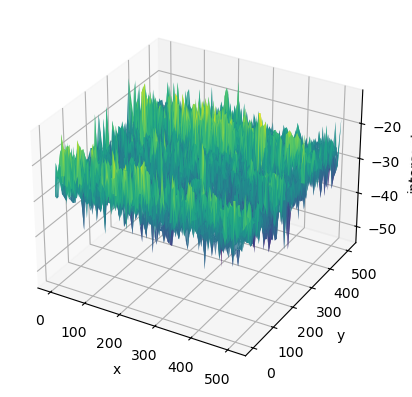

In [29]:
from matplotlib.tri import Triangulation

x = best_fits_df["x"].to_numpy()
y = best_fits_df["y"].to_numpy()
z = best_fits_df["intercept"].to_numpy()

tri = Triangulation(x, y)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot_trisurf(tri, z, cmap='viridis')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("intercept")

plt.show()

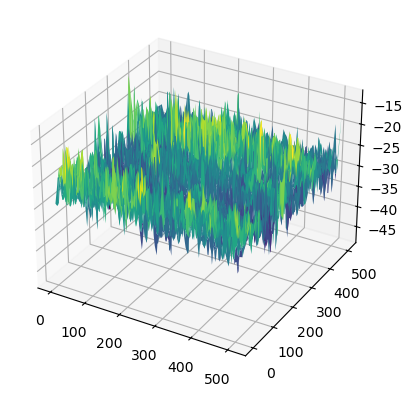

In [30]:
from scipy.interpolate import griddata
import numpy as np

x = best_fits_df["x"].to_numpy()
y = best_fits_df["y"].to_numpy()
z = best_fits_df["intercept"].to_numpy()

# Create regular grid
grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 200),
    np.linspace(y.min(), y.max(), 200)
)

# Interpolate
grid_z = griddata((x, y), z, (grid_x, grid_y), method='linear')

# Plot
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot_surface(grid_x, grid_y, grid_z, cmap='viridis')

plt.show()

In [31]:
# Plotting using plotly:
 
# Create the surface plot
fig = go.Figure(
    data = [go.Surface(
        x=x, 
        y=y, 
        z=grid_z, 
    )]
)
# Add the axis labels
fig.update_layout(
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='Intercept'
    )
)
fig.update_layout(
    autosize=False,
    width=1200,  # Desired width in pixels
    height=700   # Desired height in pixels
)

fig.show()

Text(0.5, 1.0, 'Best Fit for Pixel (195, 160) \nIntercept: -28.97, Quasi-Fermi Level Split: 0.73 eV \nStart index: 72 (1.17 eV), Stop index: 108 (1.26 eV) \nNumber of points: 36, $R^2$ = 0.9962')

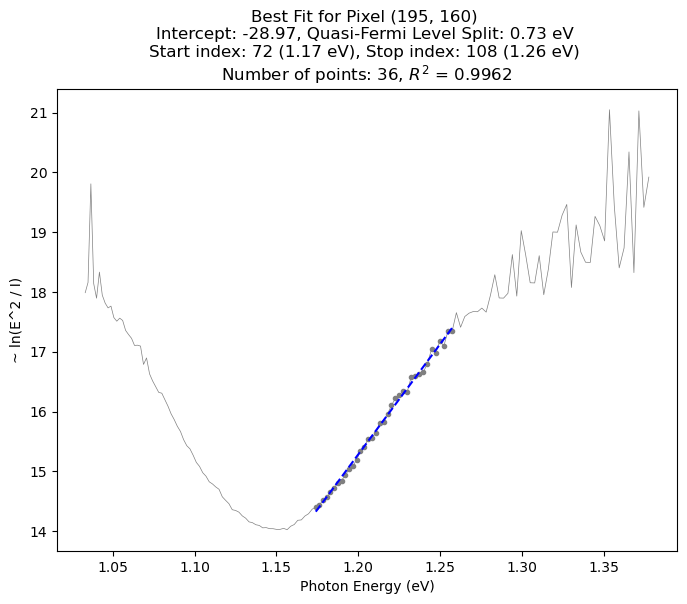

In [21]:
plt.figure(figsize=(8, 6))

# Get data for a random pixel
random_row_idx = 1000
x = int(best_fits_df.loc[random_row_idx, 'x'])
y = int(best_fits_df.loc[random_row_idx, 'y'])
idx_start = int(best_fits_df.loc[random_row_idx, 'start idx'])
idx_stop = int(best_fits_df.loc[random_row_idx, 'stop idx'])
intercept = float(best_fits_df.loc[random_row_idx, 'intercept'])
slope = float(best_fits_df.loc[random_row_idx, 'slope'])
R2 = float(best_fits_df.loc[random_row_idx, 'R2'])
qfls = float(best_fits_df.loc[random_row_idx, 'qfls'])

# Select the intensity spectrum for the pixel
amp = curve_to_fit[:, x, y]
energy = photon_energy

# Plot intensity spectrum with dots for fitting window
plt.plot(energy, amp, linewidth=0.5, color='grey')
plt.plot(energy[idx_start:idx_stop], amp[idx_start:idx_stop], color='grey', linestyle='none', marker='o', markersize=3)

# Plot the trendline
trendline_x = energy[idx_start:idx_stop]
trendline_y = intercept + slope * trendline_x
plt.plot(trendline_x, trendline_y, color='blue', linestyle='--')
plt.xlabel('Photon Energy (eV)')
plt.ylabel('~ ln(E^2 / I)')
plt.title(
    f'Best Fit for Pixel ({x}, {y}) \n' +
    f'Intercept: {intercept:.2f}, Quasi-Fermi Level Split: {qfls:.2f} eV \n' + 
    f'Start index: {idx_start} ({energy[idx_start]:.2f} eV), Stop index: {idx_stop} ({energy[idx_stop]:.2f} eV) \n' + 
    f'Number of points: {idx_stop - idx_start}, $R^2$ = {R2:.4f}'
)


### Plotting Trendlines

In [8]:
# Generating plots for each pixel
fig, ax = plt.subplots(figsize=(8, 6)) # Reuse for each plot to save time

# Make folder for storage
path, filename_ext = os.path.split(spectra_file)
filename = os.path.splitext(filename_ext)[0]
image_folder = os.path.join(path, filename + '-_best_fits-min_window_10')
os.makedirs(image_folder, exist_ok=True)

for idx, row in tqdm(best_fits_df.iterrows()): 
    x = int(row['x'])
    y = int(row['y'])
    idx_start = int(row['start idx'])
    idx_stop = int(row['stop idx'])
    intercept = float(row['intercept'])
    slope = float(row['slope'])
    R2 = float(row['R2'])
    qfls = float(row['qfls'])

    # Select the intensity spectrum for the pixel
    amp = curve_to_fit[:, x, y]
    energy = photon_energy

    # Plot intensity spectrum with dots for fitting window
    ax.clear()
    ax.plot(energy, amp, linewidth=0.5, color='grey')
    ax.plot(energy[idx_start:idx_stop], amp[idx_start:idx_stop], color='grey', linestyle='none', marker='o', markersize=3)

    # Plot the trendline
    trendline_x = energy[idx_start:idx_stop]
    trendline_y = intercept + slope * trendline_x
    ax.plot(trendline_x, trendline_y, color='blue', linestyle='--')
    ax.set_xlabel('Photon Energy (eV)')
    ax.set_ylabel('~ ln(E^2 / I)')
    ax.set_title(
        f'Best Fit for Pixel ({x}, {y}) \n' +
        f'Intercept: {intercept:.2f}, Quasi-Fermi Level Split: {qfls:.2f} eV \n' + 
        f'Start index: {idx_start} ({energy[idx_start]:.2f} eV), Stop index: {idx_stop} ({energy[idx_stop]:.2f} eV) \n' + 
        f'Number of points: {idx_stop - idx_start}, R² = {R2:.4f}'
    )
    fig.savefig(os.path.join(image_folder, f'{x:03d}x_{y:03d}y.png'), dpi=150, bbox_inches="tight")

2622it [14:00,  3.12it/s]


In [ ]:
x = int(row['x'])
y = int(row['y'])
idx_start = int(row['start idx'])
idx_stop = int(row['stop idx'])
intercept = float(row['intercept'])
slope = float(row['slope'])
R2 = float(row['R2'])
qfls = float(row['qfls'])

# Select the intensity spectrum for the pixel
amp = curve_to_fit[:, x, y]
energy = photon_energy

# Plot intensity spectrum with dots for fitting window
ax.clear()
ax.plot(energy, amp, linewidth=0.5, color='grey')
ax.plot(energy[idx_start:idx_stop], amp[idx_start:idx_stop], color='grey', linestyle='none', marker='o', markersize=3)

# Plot the trendline
trendline_x = energy[idx_start:idx_stop]
trendline_y = intercept + slope * trendline_x
ax.plot(trendline_x, trendline_y, color='blue', linestyle='--')
ax.set_xlabel('Photon Energy (eV)')
ax.set_ylabel('~ ln(E^2 / I)')
ax.set_title(
    f'Best Fit for Pixel ({x}, {y}) \n' +
    f'Intercept: {intercept:.2f}, Quasi-Fermi Level Split: {qfls:.2f} eV \n' + 
    f'Start index: {idx_start} ({energy[idx_start]:.2f} eV), Stop index: {idx_stop} ({energy[idx_stop]:.2f} eV) \n' + 
    f'Number of points: {idx_stop - idx_start}, R² = {R2:.4f}'
)
plt.savefig(os.path.join(image_folder, f'{x:03d}x_{y:03d}y.png'), dpi=150, bbox_inches="tight")
plt.close()